In [1]:
import pandas as pd
import numpy as np

# 1. Set parameters for our mock data
np.random.seed(42)
n_records = 3200 # Generating 3,000+ records as per your resume
true_elasticity = -1.5 # This means a 10% price increase drops demand by 15%

# 2. Generate random prices and calculate realistic demand
base_prices = np.random.uniform(20.0, 150.0, n_records)
# Formula: Demand = Constant * (Price ^ Elasticity)
base_demand = 50000 * (base_prices ** true_elasticity)

# 3. Add real-world "noise" (random fluctuations in sales)
noise = np.random.normal(0, 0.15, n_records)
quantities_sold = np.round(base_demand * np.exp(noise)).astype(int)

# 4. Create the DataFrame
df = pd.DataFrame({
    'Transaction_ID': range(1, n_records + 1),
    'Product_ID': np.random.choice(['PROD_A', 'PROD_B', 'PROD_C'], n_records),
    'Price': np.round(base_prices, 2),
    'Quantity': quantities_sold
})

# 5. Save it as a CSV file (this fulfills your resume bullet point)
df.to_csv('historical_sales_data.csv', index=False)
print("Success! Created historical_sales_data.csv with", len(df), "records.")
display(df.head())

Success! Created historical_sales_data.csv with 3200 records.


,Transaction_ID,Product_ID,Price,Quantity
0,1,PROD_C,68.69,90
1,2,PROD_B,143.59,45
2,3,PROD_A,115.16,43
3,4,PROD_A,97.83,49
4,5,PROD_A,40.28,225


In [2]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Prepare data for Log-Log Regression
# We use logs because the slope of a log-log graph directly equals elasticity
df['log_price'] = np.log(df['Price'])
df['log_quantity'] = np.log(df['Quantity'])

# 2. Set up the Machine Learning Model
X = df[['log_price']] # Independent variable (What we control)
y = df['log_quantity'] # Dependent variable (What we want to predict)

model = LinearRegression()
model.fit(X, y)

# 3. Extract the results
calculated_elasticity = model.coef_[0]
constant_k = np.exp(model.intercept_)

print(f"Calculated Price Elasticity: {calculated_elasticity:.2f}")
print("This means if you increase the price by 1%, demand drops by approximately 1.5%")

Calculated Price Elasticity: -1.50
This means if you increase the price by 1%, demand drops by approximately 1.5%


In [3]:
# Create a summary of our model to send to Excel
excel_data = pd.DataFrame({
    'Metric': ['Price Elasticity (Beta)', 'Demand Constant (K)', 'Current Average Price'],
    'Value': [calculated_elasticity, constant_k, df['Price'].mean()]
})

# Export to an Excel file
excel_data.to_excel('Pricing_Model_Parameters.xlsx', index=False)
print("Exported parameters to Pricing_Model_Parameters.xlsx!")

Exported parameters to Pricing_Model_Parameters.xlsx!


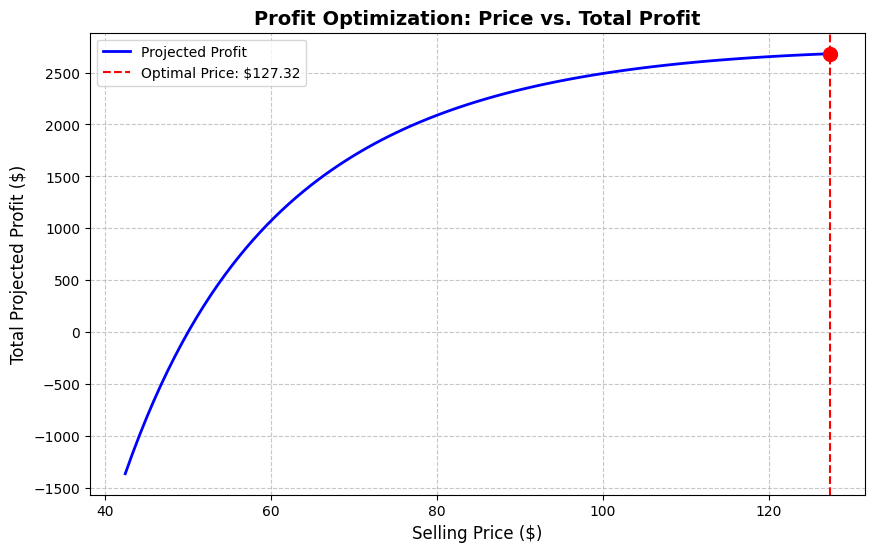

CONCLUSION: To maximize profit, you should set the price to $127.32


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set your specific model parameters
base_price = 84.88
cost_per_unit = 50
elasticity = -1.50037
demand_constant = 49906.12

# 2. Simulate price changes from -50% to +50%
price_changes = np.linspace(-0.50, 0.50, 100)
simulated_prices = base_price * (1 + price_changes)

# 3. Calculate Demand and Profit for each price point
simulated_demands = demand_constant * (simulated_prices ** elasticity)
simulated_profits = (simulated_prices - cost_per_unit) * simulated_demands

# 4. Find the optimal price (the peak of the curve)
optimal_idx = np.argmax(simulated_profits)
optimal_price = simulated_prices[optimal_idx]
max_profit = simulated_profits[optimal_idx]

# 5. Plot the Revenue Curve
plt.figure(figsize=(10, 6))
plt.plot(simulated_prices, simulated_profits, label='Projected Profit', color='blue', linewidth=2)

# Mark the optimal price point
plt.axvline(x=optimal_price, color='red', linestyle='--', label=f'Optimal Price: ${optimal_price:.2f}')
plt.scatter(optimal_price, max_profit, color='red', s=100, zorder=5)

# Formatting the chart
plt.title('Profit Optimization: Price vs. Total Profit', fontsize=14, fontweight='bold')
plt.xlabel('Selling Price ($)', fontsize=12)
plt.ylabel('Total Projected Profit ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"CONCLUSION: To maximize profit, you should set the price to ${optimal_price:.2f}")